In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.holtwinters import Holt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [15]:
df = yf.download("AAPL",
                 start="2020-01-01",
                 end="2022-01-01",
                 auto_adjust=True)

df = df[['Close']]
df.dropna(inplace=True)

print(df.head())

[*********************100%***********************]  1 of 1 completed

Price           Close
Ticker           AAPL
Date                 
2020-01-02  72.333878
2020-01-03  71.630638
2020-01-06  72.201408
2020-01-07  71.861862
2020-01-08  73.017830


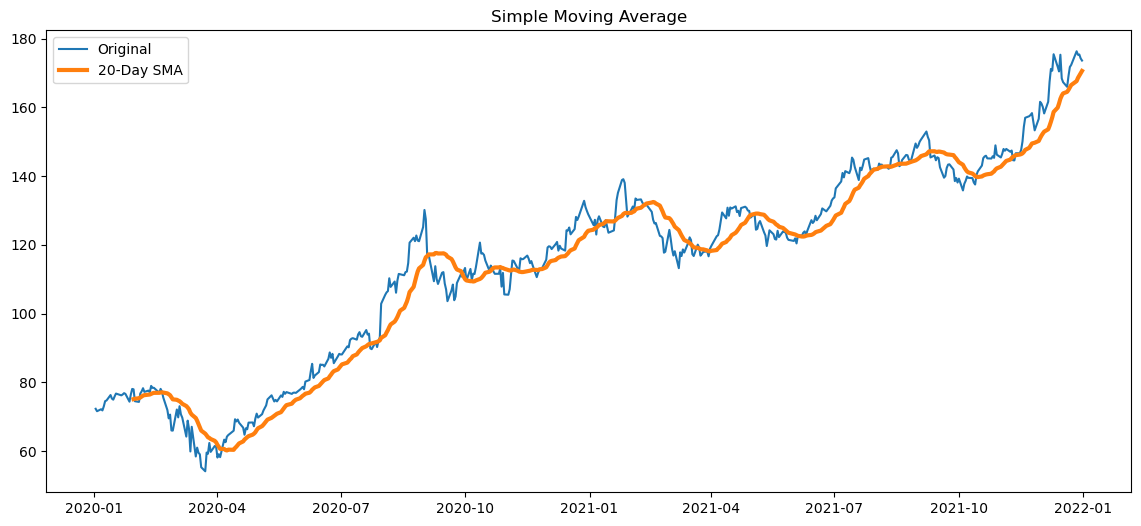

In [16]:
df['SMA_20'] = df['Close'].rolling(window=20).mean()

plt.figure(figsize=(14,6))
plt.plot(df['Close'], label='Original')
plt.plot(df['SMA_20'], label='20-Day SMA', linewidth=3)
plt.title("Simple Moving Average")
plt.legend()
plt.show()

# Exponential Moving Average (EMA)

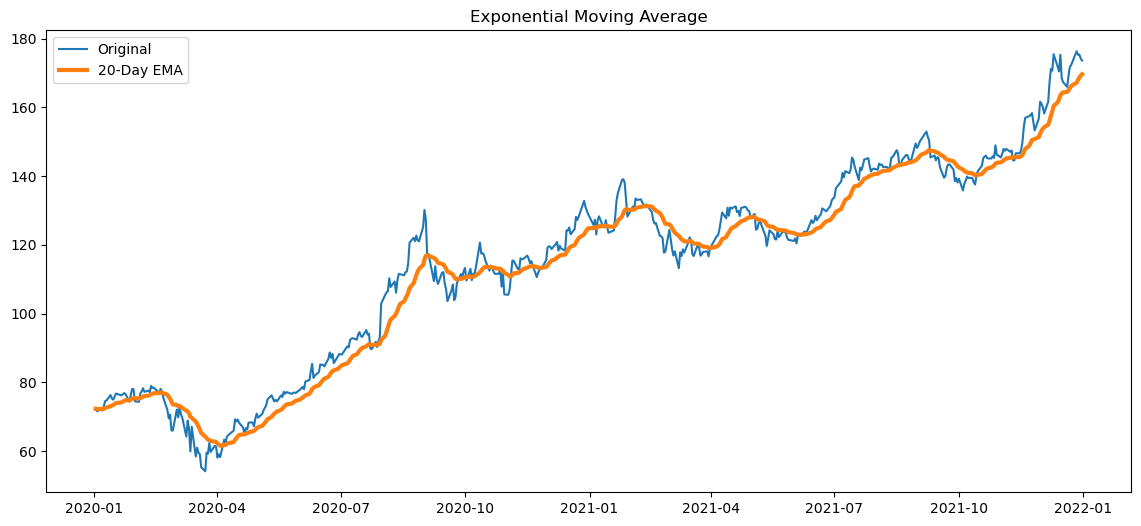

In [17]:
df['EMA_20'] = df['Close'].ewm(span=20, adjust=False).mean()

plt.figure(figsize=(14,6))
plt.plot(df['Close'], label='Original')
plt.plot(df['EMA_20'], label='20-Day EMA', linewidth=3)
plt.title("Exponential Moving Average")
plt.legend()
plt.show()

# 3. Simple Exponential Smoothing (SES)

C:\Users\karth\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


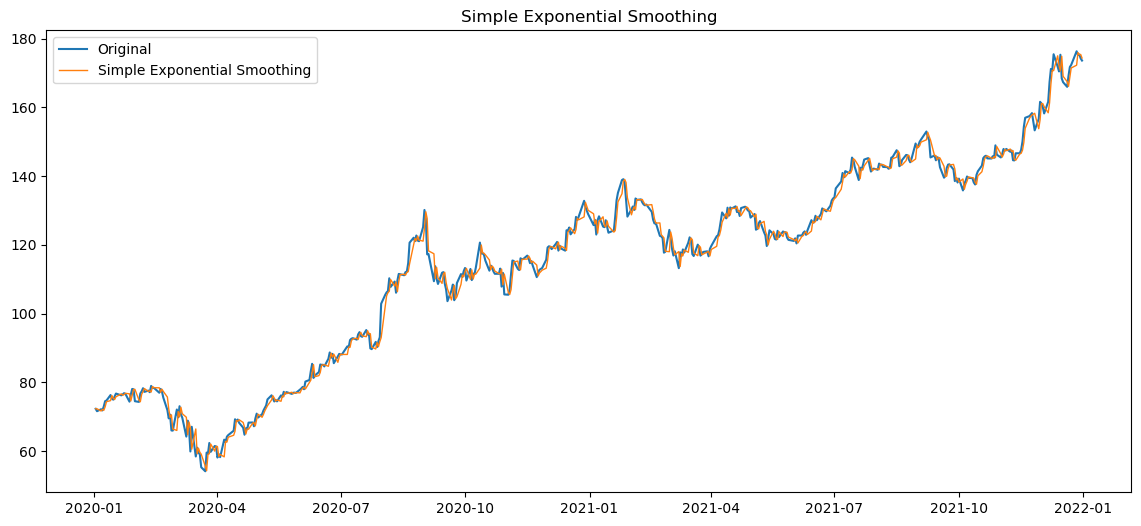

In [18]:
ses_model = SimpleExpSmoothing(df['Close']).fit()

df['SES'] = ses_model.fittedvalues

plt.figure(figsize=(14,6))
plt.plot(df['Close'], label='Original')
plt.plot(df['SES'], label='Simple Exponential Smoothing', linewidth=1)
plt.title("Simple Exponential Smoothing")
plt.legend()
plt.show()

# Double Exponential Smoothing (Holt's Linear Trend)

C:\Users\karth\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


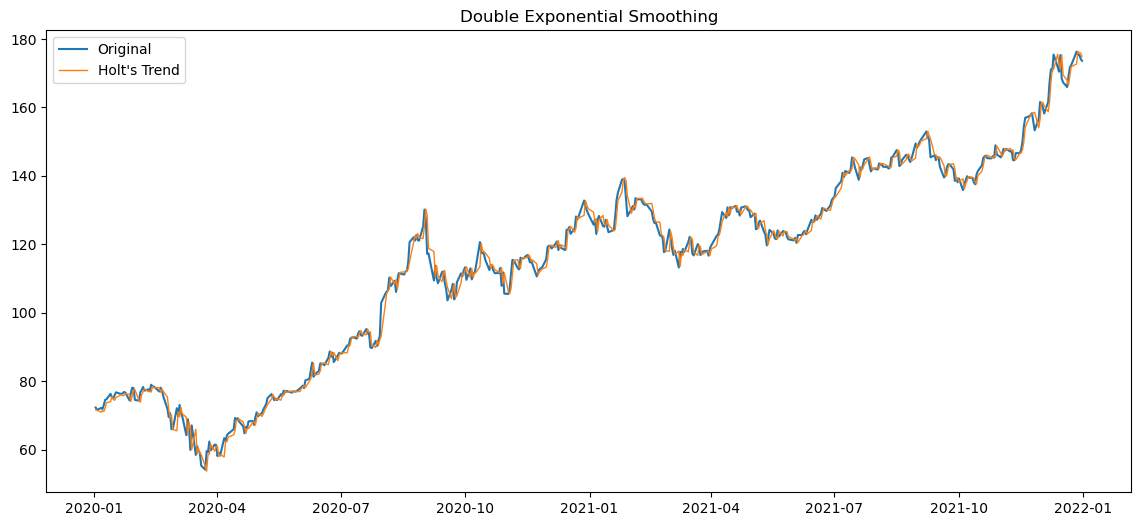

In [19]:
holt_model = Holt(df['Close']).fit()

df['Holt'] = holt_model.fittedvalues

plt.figure(figsize=(14,6))
plt.plot(df['Close'], label='Original')
plt.plot(df['Holt'], label="Holt's Trend", linewidth=1)
plt.title("Double Exponential Smoothing")
plt.legend()
plt.show()

# 5. Triple Exponential Smoothing (Holt-Winters)

C:\Users\karth\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


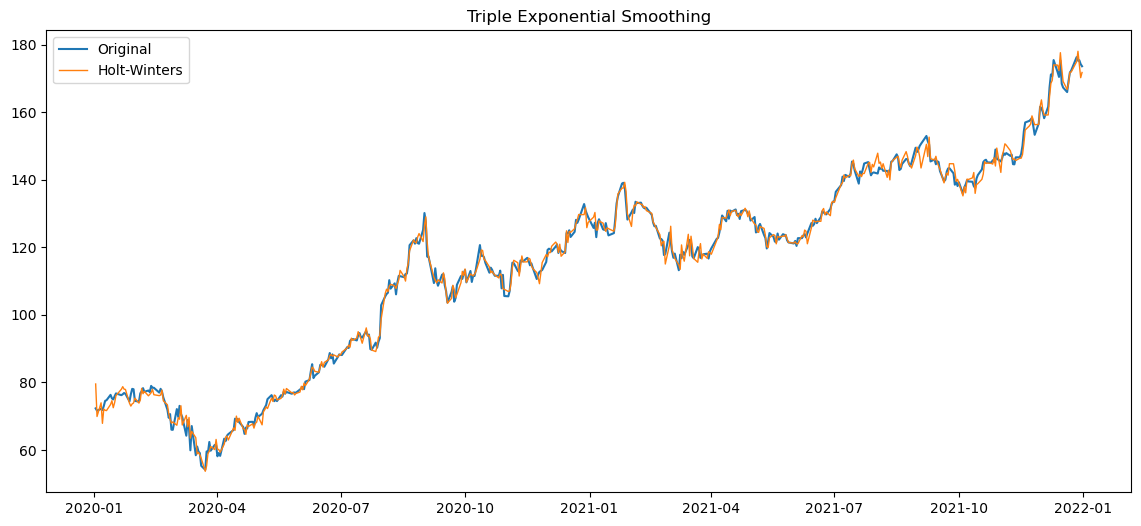

In [20]:
hw_model = ExponentialSmoothing(
    df['Close'],
    trend='add',
    seasonal='add',
    seasonal_periods=252
).fit()

df['Holt_Winters'] = hw_model.fittedvalues

plt.figure(figsize=(14,6))
plt.plot(df['Close'], label='Original')
plt.plot(df['Holt_Winters'], label='Holt-Winters', linewidth=1)
plt.title("Triple Exponential Smoothing")
plt.legend()
plt.show()

# Compare All Methods

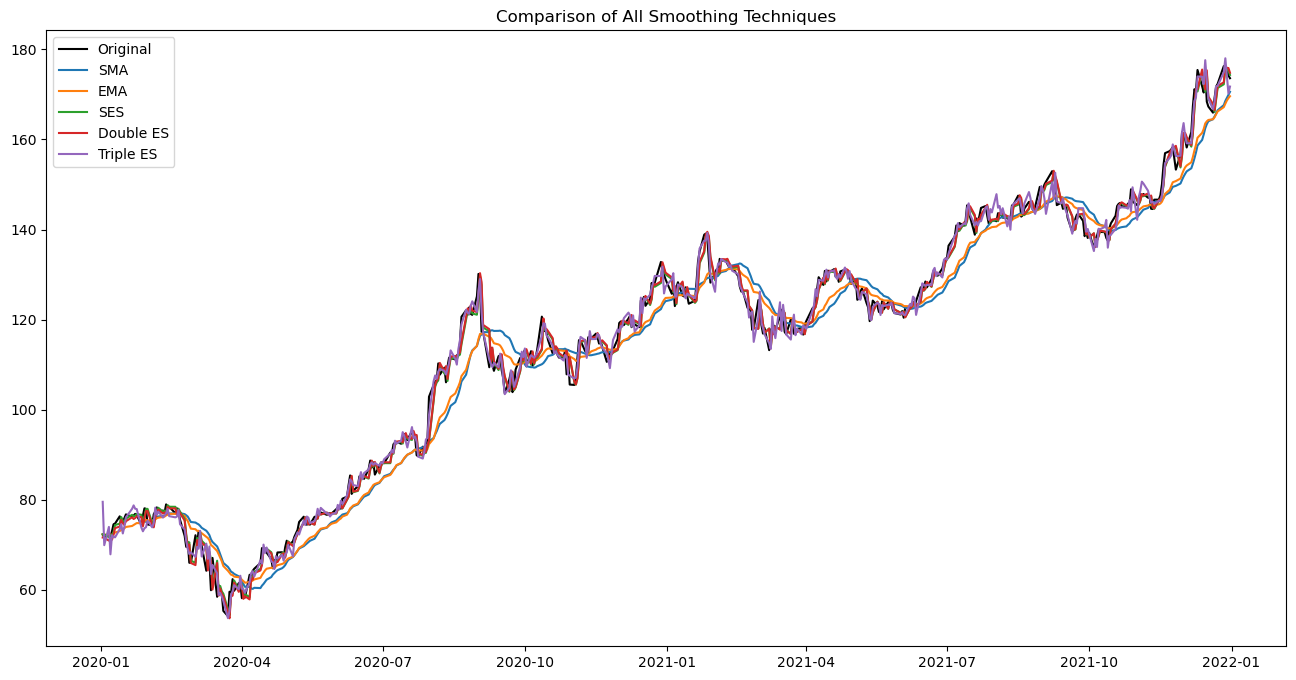

In [21]:
plt.figure(figsize=(16,8))

plt.plot(df['Close'], label='Original', color='black')

plt.plot(df['SMA_20'], label='SMA')

plt.plot(df['EMA_20'], label='EMA')

plt.plot(df['SES'], label='SES')

plt.plot(df['Holt'], label='Double ES')

plt.plot(df['Holt_Winters'], label='Triple ES')

plt.title("Comparison of All Smoothing Techniques")
plt.legend()
plt.show()